# Comprehensive Feature Selection — All Methods
**Target:** `psychological_risk = z(stress) - z(happiness)`  
**Output:** Top-N features ranked by ensemble of all methods

### Methods covered
| # | Category | Method |
|---|----------|--------|
| 1 | Filter | Mutual Information |
| 2 | Filter | Spearman Correlation |
| 3 | Filter | F-Statistic (f_regression) |
| 4 | Filter | Variance Inflation Factor (VIF) |
| 5 | Embedded | ElasticNet (L1+L2) |
| 6 | Embedded | ExtraTrees built-in importance |
| 7 | Embedded | LightGBM gain importance |
| 8 | Embedded | SHAP values (TreeExplainer on LGB) |
| 9 | Wrapper | RFECV (recursive feature elimination) |
| 10 | Wrapper | Boruta |
| 11 | Stability | Stability Selection (bootstrap LASSO) |
| 12 | Stability | Permutation Importance (OOF) |
| — | Ensemble | Borda Count rank aggregation → Top-N |


## 0. Installs

In [4]:
# Run once — comment out after first execution
!pip install lightgbm boruta shap --quiet

## 1. Config — edit here

In [5]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

# ── File ──────────────────────────────────────────────────────────────
INPUT          = Path("instagram_usage_lifestyle.csv")

# ── Target construction ───────────────────────────────────────────────
STRESS_COL     = "perceived_stress_score"
HAPPY_COL      = "self_reported_happiness"
TARGET         = "psychological_risk"       # z(stress) - z(happiness)

# ── Columns to drop ───────────────────────────────────────────────────
DROP_COLS      = ["user_id"]                # IDs / row identifiers
LEAKAGE_COLS   = [STRESS_COL, HAPPY_COL]   # used to build target — excluded from features

# ── Output ────────────────────────────────────────────────────────────
TOP_N          = 20                         # ← change as needed
OUT_RANK_CSV   = Path(f"feature_rankings_all_methods.csv")
OUT_TOPN_TXT   = Path(f"top{TOP_N}_features.txt")

# ── Sampling (set to None to use full dataset) ────────────────────────
N_SAMPLE_FAST  = 100_000   # MI, Spearman, F-stat
N_SAMPLE_MED   = 80_000    # ElasticNet, ExtraTrees, LGB, SHAP
N_SAMPLE_SLOW  = 50_000    # RFECV, Boruta, Stability, Permutation

RANDOM_STATE   = 42

print(f"Config loaded. TOP_N={TOP_N}, Input={INPUT}")

Config loaded. TOP_N=20, Input=instagram_usage_lifestyle.csv


## 2. Imports

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (
    mutual_info_regression, f_regression,
    RFECV, SelectFromModel
)
from sklearn.linear_model import ElasticNetCV, LassoCV
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.inspection import permutation_importance

import lightgbm as lgb
import shap
from boruta import BorutaPy

print("All imports OK")

All imports OK


## 3. Helper utilities

In [7]:
# ── Sampling ──────────────────────────────────────────────────────────
def sample_xy(X, y, n, seed=RANDOM_STATE):
    if n is None or len(X) <= n:
        return X.copy(), y.copy()
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X), size=n, replace=False)
    return X.iloc[idx].copy(), y.iloc[idx].copy()

# ── Type detection ────────────────────────────────────────────────────
def detect_types(X):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]
    return num_cols, cat_cols

# ── Ordinal-encode a df for tree/MI methods ───────────────────────────
def ordinal_encode(X, num_cols, cat_cols):
    X_num = X[num_cols].copy().apply(pd.to_numeric, errors="coerce")
    X_num = X_num.fillna(X_num.median(numeric_only=True))
    if cat_cols:
        X_cat = X[cat_cols].astype("string").fillna("Unknown")
        oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X_cat_enc = pd.DataFrame(oe.fit_transform(X_cat), columns=cat_cols, index=X_cat.index)
        return pd.concat([X_num, X_cat_enc], axis=1)
    return X_num

# ── Full sklearn preprocessor (for ElasticNet etc.) ──────────────────
def make_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                         ("sc",  StandardScaler())])
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
    cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                         ("ohe", ohe)])
    transformers = [("num", num_pipe, num_cols)]
    if cat_cols:
        transformers.append(("cat", cat_pipe, cat_cols))
    return ColumnTransformer(transformers)

# ── Date → numeric in-place ───────────────────────────────────────────
def convert_date_inplace(df, col="last_login_date"):
    if col not in df.columns:
        return
    dt = pd.to_datetime(df[col], errors="coerce", utc=True)
    df[col] = (dt.view("int64") // (10**9) / 86400).astype("float64")

# ── Build target ──────────────────────────────────────────────────────
def build_psychological_risk(df):
    s = pd.to_numeric(df[STRESS_COL], errors="coerce")
    h = pd.to_numeric(df[HAPPY_COL],  errors="coerce")
    s_z = (s - s.mean()) / (s.std(ddof=0) or 1.0)
    h_z = (h - h.mean()) / (h.std(ddof=0) or 1.0)
    return (s_z - h_z).astype("float64")

# ── Borda count aggregation ───────────────────────────────────────────
def borda_aggregate(rank_cols_df):
    """Given a DataFrame of per-method ranks, return Borda score (lower = better)."""
    return rank_cols_df.mean(axis=1)

print("Helpers defined")

Helpers defined


## 4. Load & preprocess data

In [8]:
df = pd.read_csv(INPUT, low_memory=False)
print(f"Raw shape: {df.shape}")

# Numeric coercion
numeric_candidates = [
    "age","exercise_hours_per_week","sleep_hours_per_night","body_mass_index",
    "blood_pressure_systolic","blood_pressure_diastolic","daily_steps_count",
    "weekly_work_hours","hobbies_count","social_events_per_month","books_read_per_year",
    "volunteer_hours_per_month","travel_frequency_per_year","daily_active_minutes_instagram",
    "sessions_per_day","posts_created_per_week","reels_watched_per_day","stories_viewed_per_day",
    "likes_given_per_day","comments_written_per_day","dms_sent_per_week","dms_received_per_week",
    "ads_viewed_per_day","ads_clicked_per_day","time_on_feed_per_day","time_on_explore_per_day",
    "time_on_messages_per_day","time_on_reels_per_day","followers_count","following_count",
    "notification_response_rate","account_creation_year","average_session_length_minutes",
    "linked_accounts_count","user_engagement_score",
    STRESS_COL, HAPPY_COL
]
for c in numeric_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

convert_date_inplace(df)
df[TARGET] = build_psychological_risk(df)
df = df.loc[df[TARGET].notna()].copy()
print(f"After target build: {df.shape}")

# Build X, y
drop_all = [c for c in DROP_COLS + LEAKAGE_COLS if c in df.columns]
X_raw = df.drop(columns=[TARGET] + drop_all, errors="ignore")
y     = df[TARGET].astype(float).reset_index(drop=True)
X_raw = X_raw.reset_index(drop=True)

num_cols, cat_cols = detect_types(X_raw)
print(f"Features: {X_raw.shape[1]}  |  Numeric: {len(num_cols)}  |  Categorical: {len(cat_cols)}")

Raw shape: (1547896, 58)
After target build: (1547896, 59)
Features: 55  |  Numeric: 36  |  Categorical: 19


## 5. Results collector

In [9]:
# Master dict: method_name -> pd.Series(score, index=feature_name)
scores = {}
# Higher score = more important for ALL methods stored here
print("Score collector initialised")

Score collector initialised


---
## Method 1 — Mutual Information

In [10]:
print("[1/12] Mutual Information...")
Xs, ys = sample_xy(X_raw, y, N_SAMPLE_FAST)
X_enc  = ordinal_encode(Xs, num_cols, cat_cols)
discrete_mask = np.array([c in cat_cols for c in X_enc.columns])

mi = mutual_info_regression(X_enc.values, ys.values,
                             discrete_features=discrete_mask,
                             random_state=RANDOM_STATE)
scores["MI"] = pd.Series(mi, index=X_enc.columns)
print(f"  Top 5: {scores['MI'].nlargest(5).index.tolist()}")

[1/12] Mutual Information...
  Top 5: ['daily_active_minutes_instagram', 'likes_given_per_day', 'time_on_feed_per_day', 'stories_viewed_per_day', 'time_on_reels_per_day']


## Method 2 — Spearman Correlation

In [11]:
print("[2/12] Spearman Correlation...")
Xs, ys = sample_xy(X_raw, y, N_SAMPLE_FAST)
X_enc  = ordinal_encode(Xs, num_cols, cat_cols)

spearman_scores = {}
for col in X_enc.columns:
    rho, _ = stats.spearmanr(X_enc[col].values, ys.values, nan_policy="omit")
    spearman_scores[col] = abs(rho) if not np.isnan(rho) else 0.0

scores["Spearman"] = pd.Series(spearman_scores)
print(f"  Top 5: {scores['Spearman'].nlargest(5).index.tolist()}")

[2/12] Spearman Correlation...
  Top 5: ['daily_active_minutes_instagram', 'likes_given_per_day', 'time_on_feed_per_day', 'stories_viewed_per_day', 'time_on_reels_per_day']


## Method 3 — F-Statistic

In [12]:
print("[3/12] F-Statistic (f_regression)...")
Xs, ys = sample_xy(X_raw, y, N_SAMPLE_FAST)
X_enc  = ordinal_encode(Xs, num_cols, cat_cols)
# Impute any remaining NaNs for f_regression
X_filled = X_enc.fillna(X_enc.median(numeric_only=True))

f_vals, p_vals = f_regression(X_filled.values, ys.values)
f_vals = np.nan_to_num(f_vals, nan=0.0)

scores["F_stat"] = pd.Series(f_vals, index=X_filled.columns)
print(f"  Top 5: {scores['F_stat'].nlargest(5).index.tolist()}")

[3/12] F-Statistic (f_regression)...
  Top 5: ['daily_active_minutes_instagram', 'likes_given_per_day', 'time_on_feed_per_day', 'stories_viewed_per_day', 'comments_written_per_day']


## Method 4 — Variance Inflation Factor (VIF)
> VIF measures multicollinearity — **low VIF = feature is non-redundant**.  
> We invert VIF so higher score still means "more useful".

In [13]:
print("[4/12] Variance Inflation Factor (VIF)...")
# VIF only makes sense on numeric columns; sample to keep it fast
Xs, ys = sample_xy(X_raw, y, min(N_SAMPLE_FAST, 30_000))
X_num_only = Xs[num_cols].apply(pd.to_numeric, errors="coerce")
X_num_only = X_num_only.fillna(X_num_only.median(numeric_only=True))

# Drop constant columns before VIF
X_num_only = X_num_only.loc[:, X_num_only.std() > 0]

vif_vals = {}
arr = X_num_only.values.astype(float)
for i, col in enumerate(X_num_only.columns):
    try:
        v = variance_inflation_factor(arr, i)
    except Exception:
        v = np.nan
    vif_vals[col] = v

vif_series = pd.Series(vif_vals)
# Invert: 1/VIF (higher = less collinear = prefer)
# Cap VIF at 1000 to avoid inf from near-perfect collinearity
vif_series = vif_series.clip(upper=1000).replace(0, np.nan).fillna(1000)
scores["VIF_inv"] = 1.0 / vif_series

# Also expose raw VIF as a reference table
vif_df = pd.DataFrame({"feature": list(vif_vals.keys()),
                        "VIF": list(vif_vals.values())}).sort_values("VIF")
print("  Lowest VIF (least collinear) features:")
print(vif_df.head(10).to_string(index=False))

[4/12] Variance Inflation Factor (VIF)...
  Lowest VIF (least collinear) features:
                   feature      VIF
           followers_count 2.975094
     linked_accounts_count 3.126403
 volunteer_hours_per_month 3.693376
           following_count 4.007235
             hobbies_count 4.019165
 travel_frequency_per_year 4.024490
notification_response_rate 4.085302
     user_engagement_score 4.089732
   exercise_hours_per_week 4.203800
   social_events_per_month 5.015542


## Method 5 — ElasticNet

In [14]:
print("[5/12] ElasticNet...")
Xs, ys = sample_xy(X_raw, y, N_SAMPLE_MED)

pre    = make_preprocessor(num_cols, cat_cols)
model  = ElasticNetCV(l1_ratio=[0.1,0.5,0.9,0.95,1.0], cv=5,
                      random_state=RANDOM_STATE, n_jobs=-1, max_iter=5000)
pipe   = Pipeline([("prep", pre), ("model", model)])
pipe.fit(Xs, ys)

coefs  = pipe["model"].coef_
importance = {}
offset = 0
for i, col in enumerate(num_cols):
    importance[col] = float(abs(coefs[i]))
offset = len(num_cols)
if cat_cols:
    ohe = pipe["prep"].named_transformers_["cat"]["ohe"]
    cat_coefs = coefs[offset:]
    start = 0
    for col, cats in zip(cat_cols, ohe.categories_):
        k = len(cats)
        importance[col] = float(np.abs(cat_coefs[start:start+k]).sum())
        start += k

scores["ElasticNet"] = pd.Series(importance)
print(f"  Top 5: {scores['ElasticNet'].nlargest(5).index.tolist()}")

[5/12] ElasticNet...
  Top 5: ['daily_active_minutes_instagram', 'age', 'user_engagement_score', 'likes_given_per_day', 'comments_written_per_day']


## Method 6 — ExtraTrees built-in importance

In [15]:
print("[6/12] ExtraTrees built-in importance...")
Xs, ys = sample_xy(X_raw, y, N_SAMPLE_MED)
X_enc  = ordinal_encode(Xs, num_cols, cat_cols)

et = ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_STATE,
                         n_jobs=-1, max_features="sqrt", min_samples_leaf=2)
et.fit(X_enc, ys)
scores["ExtraTrees"] = pd.Series(et.feature_importances_, index=X_enc.columns)
print(f"  Top 5: {scores['ExtraTrees'].nlargest(5).index.tolist()}")

[6/12] ExtraTrees built-in importance...
  Top 5: ['daily_active_minutes_instagram', 'stories_viewed_per_day', 'likes_given_per_day', 'time_on_feed_per_day', 'comments_written_per_day']


## Method 7 — LightGBM gain importance

In [16]:
print("[7/12] LightGBM gain importance...")
Xs, ys = sample_xy(X_raw, y, N_SAMPLE_MED)
X_enc  = ordinal_encode(Xs, num_cols, cat_cols)

lgb_model = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05,
    num_leaves=63, random_state=RANDOM_STATE,
    n_jobs=-1, verbose=-1
)
lgb_model.fit(X_enc, ys)

gain_imp = lgb_model.booster_.feature_importance(importance_type="gain")
scores["LGB_gain"] = pd.Series(gain_imp, index=X_enc.columns)
print(f"  Top 5: {scores['LGB_gain'].nlargest(5).index.tolist()}")

[7/12] LightGBM gain importance...
  Top 5: ['daily_active_minutes_instagram', 'age', 'user_engagement_score', 'likes_given_per_day', 'time_on_feed_per_day']


## Method 8 — SHAP values (LightGBM TreeExplainer)

[8/12] SHAP values...
  Top 5: ['daily_active_minutes_instagram', 'age', 'user_engagement_score', 'likes_given_per_day', 'stories_viewed_per_day']


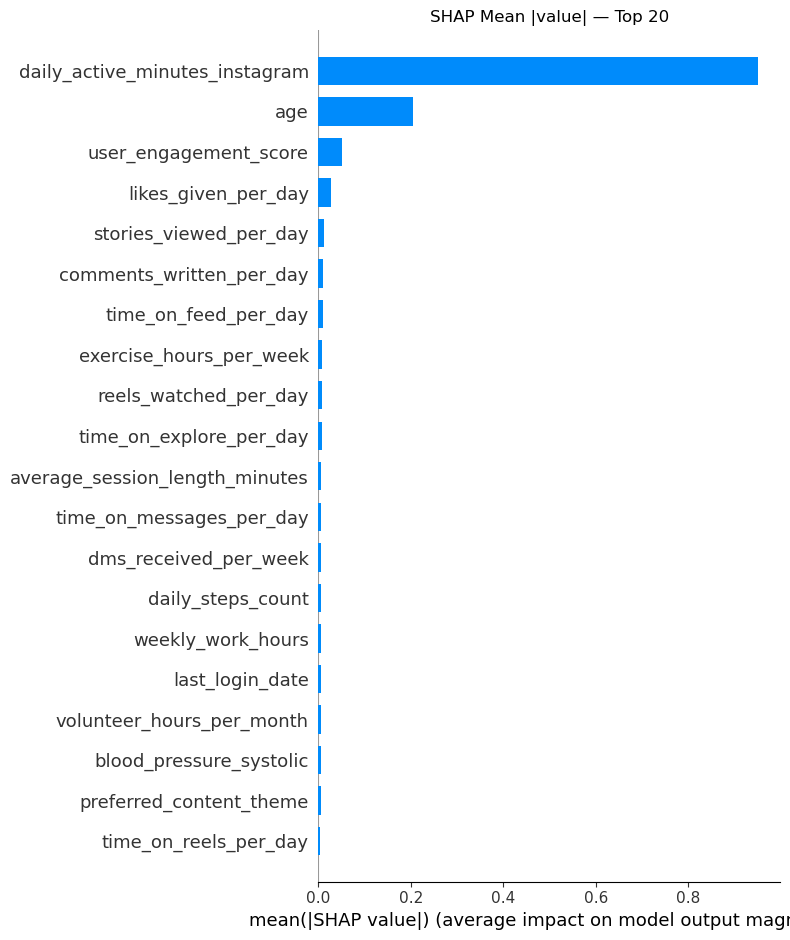

In [17]:
print("[8/12] SHAP values...")
# Re-use same lgb_model fitted above; use a subsample for SHAP speed
Xs_shap, _ = sample_xy(X_enc, ys, min(N_SAMPLE_MED, 20_000))

explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(Xs_shap)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

scores["SHAP"] = pd.Series(mean_abs_shap, index=X_enc.columns)
print(f"  Top 5: {scores['SHAP'].nlargest(5).index.tolist()}")

# SHAP summary plot
shap.summary_plot(shap_values, Xs_shap,
                  max_display=20, plot_type="bar", show=False)
plt.title("SHAP Mean |value| — Top 20")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=120)
plt.show()

## Method 9 — RFECV (Recursive Feature Elimination w/ cross-validation)

In [18]:
print("[9/12] RFECV... (may take a few minutes)")
Xs, ys = sample_xy(X_raw, y, N_SAMPLE_SLOW)
X_enc  = ordinal_encode(Xs, num_cols, cat_cols)

base_est = RandomForestRegressor(n_estimators=80, max_depth=6,
                                  random_state=RANDOM_STATE, n_jobs=-1)
rfecv = RFECV(estimator=base_est, step=3, cv=KFold(5),
              scoring="r2", n_jobs=-1, min_features_to_select=5)
rfecv.fit(X_enc, ys)

# Ranking: 1 = selected (best); higher = eliminated earlier
# Invert so selected features have highest score
rfe_scores = 1.0 / rfecv.ranking_.astype(float)
scores["RFECV"] = pd.Series(rfe_scores, index=X_enc.columns)
print(f"  Optimal n_features: {rfecv.n_features_}")
print(f"  Top 5: {scores['RFECV'].nlargest(5).index.tolist()}")

[9/12] RFECV... (may take a few minutes)
  Optimal n_features: 5
  Top 5: ['age', 'daily_active_minutes_instagram', 'reels_watched_per_day', 'average_session_length_minutes', 'user_engagement_score']


## Method 10 — Boruta

In [19]:
print("[10/12] Boruta... (may take a few minutes)")
Xs, ys = sample_xy(X_raw, y, N_SAMPLE_SLOW)
X_enc  = ordinal_encode(Xs, num_cols, cat_cols).values.astype(np.float32)

boruta_rf = RandomForestRegressor(n_estimators=100, max_depth=5,
                                   random_state=RANDOM_STATE, n_jobs=-1)
boruta_sel = BorutaPy(boruta_rf, n_estimators="auto",
                      random_state=RANDOM_STATE, max_iter=50, verbose=0)
boruta_sel.fit(X_enc, ys.values)

# ranking_: 1 = confirmed (best), higher = rejected earlier
X_enc_cols = ordinal_encode(sample_xy(X_raw, y, N_SAMPLE_SLOW)[0], num_cols, cat_cols).columns
boruta_scores = 1.0 / boruta_sel.ranking_.astype(float)
scores["Boruta"] = pd.Series(boruta_scores, index=X_enc_cols)
confirmed = X_enc_cols[boruta_sel.support_].tolist()
print(f"  Confirmed features ({len(confirmed)}): {confirmed[:10]}")

[10/12] Boruta... (may take a few minutes)
  Confirmed features (9): ['age', 'daily_active_minutes_instagram', 'reels_watched_per_day', 'likes_given_per_day', 'time_on_feed_per_day', 'time_on_explore_per_day', 'time_on_reels_per_day', 'average_session_length_minutes', 'user_engagement_score']


## Method 11 — Stability Selection (bootstrap LASSO)

In [ ]:
print("[11/12] Stability Selection (LASSO bootstrap)...")
N_BOOT    = 50
SUB_FRAC  = 0.5

Xs, ys = sample_xy(X_raw, y, N_SAMPLE_SLOW)
X_enc  = ordinal_encode(Xs, num_cols, cat_cols)
# Scale for LASSO
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_enc.fillna(0))
n       = len(X_scaled)
n_sub   = int(n * SUB_FRAC)

selection_counts = np.zeros(X_enc.shape[1])
rng = np.random.RandomState(RANDOM_STATE)

for _ in range(N_BOOT):
    idx = rng.choice(n, size=n_sub, replace=False)
    lasso = LassoCV(cv=3, max_iter=2000, random_state=RANDOM_STATE, n_jobs=-1)
    lasso.fit(X_scaled[idx], ys.iloc[idx].values)
    selection_counts += (lasso.coef_ != 0).astype(float)

stability_scores = selection_counts / N_BOOT  # selection frequency in [0, 1]
scores["Stability"] = pd.Series(stability_scores, index=X_enc.columns)
print(f"  Top 5: {scores['Stability'].nlargest(5).index.tolist()}")


[11/12] Stability Selection (LASSO bootstrap)...
  Top 5: ['age', 'daily_active_minutes_instagram', 'user_engagement_score', 'likes_given_per_day', 'ads_viewed_per_day']


## Method 12 — Permutation Importance (OOF)

In [21]:
print("[12/12] Permutation Importance (OOF)...")
Xs, ys = sample_xy(X_raw, y, N_SAMPLE_SLOW)
X_enc  = ordinal_encode(Xs, num_cols, cat_cols)

perm_model = RandomForestRegressor(n_estimators=100, max_depth=6,
                                    random_state=RANDOM_STATE, n_jobs=-1)
perm_model.fit(X_enc, ys)

perm_result = permutation_importance(
    perm_model, X_enc, ys,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
perm_scores = np.clip(perm_result.importances_mean, 0, None)  # clip negatives to 0
scores["Permutation"] = pd.Series(perm_scores, index=X_enc.columns)
print(f"  Top 5: {scores['Permutation'].nlargest(5).index.tolist()}")

[12/12] Permutation Importance (OOF)...
  Top 5: ['daily_active_minutes_instagram', 'age', 'user_engagement_score', 'average_session_length_minutes', 'dms_sent_per_week']


---
## 6. Borda Count Rank Aggregation

In [22]:
all_features = X_raw.columns.tolist()

rank_df = pd.DataFrame(index=all_features)
rank_df.index.name = "feature"

for method_name, score_series in scores.items():
    # Reindex to all features; fill missing with 0
    aligned = score_series.reindex(all_features, fill_value=0.0)
    rank_df[f"score_{method_name}"]  = aligned.values
    rank_df[f"rank_{method_name}"]   = aligned.rank(ascending=False, method="average").values

rank_cols = [c for c in rank_df.columns if c.startswith("rank_")]
rank_df["borda_avg_rank"] = rank_df[rank_cols].mean(axis=1)
rank_df = rank_df.sort_values("borda_avg_rank").reset_index()
rank_df["final_rank"] = np.arange(1, len(rank_df)+1)

# Save full ranking
rank_df.to_csv(OUT_RANK_CSV, index=False)

# Extract Top-N
top_n_features = rank_df.head(TOP_N)["feature"].tolist()
with open(OUT_TOPN_TXT, "w") as f:
    for feat in top_n_features:
        f.write(feat + "\n")

print(f"\n{'='*50}")
print(f"TOP {TOP_N} FEATURES (Borda Count Ensemble)")
print(f"{'='*50}")
for i, feat in enumerate(top_n_features, 1):
    print(f"  {i:02d}. {feat}")
print(f"\nSaved: {OUT_RANK_CSV}, {OUT_TOPN_TXT}")


TOP 20 FEATURES (Borda Count Ensemble)
  01. daily_active_minutes_instagram
  02. likes_given_per_day
  03. user_engagement_score
  04. time_on_feed_per_day
  05. time_on_reels_per_day
  06. average_session_length_minutes
  07. comments_written_per_day
  08. time_on_explore_per_day
  09. time_on_messages_per_day
  10. age
  11. dms_received_per_week
  12. reels_watched_per_day
  13. dms_sent_per_week
  14. ads_viewed_per_day
  15. posts_created_per_week
  16. stories_viewed_per_day
  17. volunteer_hours_per_month
  18. exercise_hours_per_week
  19. last_login_date
  20. sessions_per_day

Saved: feature_rankings_all_methods.csv, top20_features.txt


## 7. Visualisations

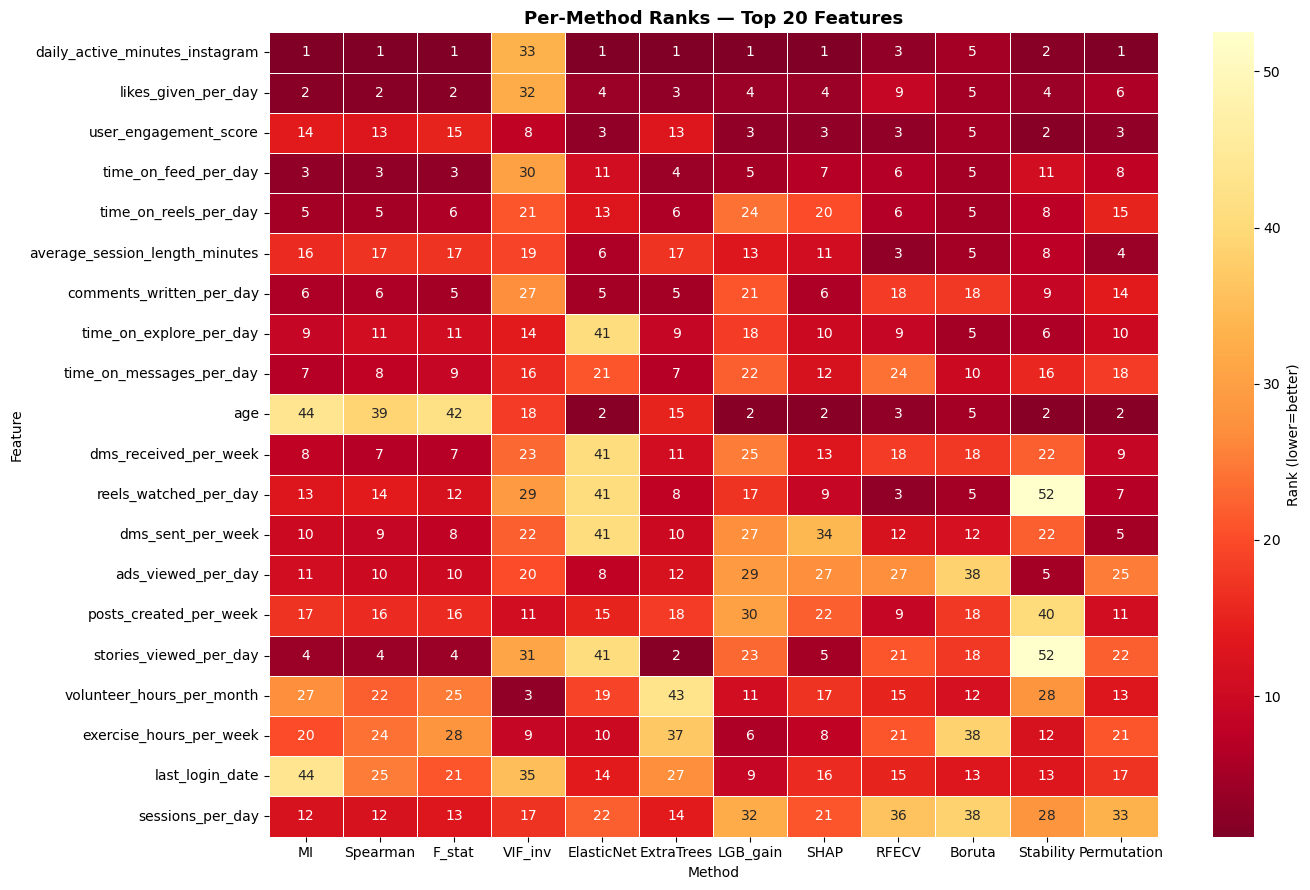

In [23]:
# ── 7A: Heatmap of per-method ranks for Top-N features ────────────────
top_rank_df = rank_df.head(TOP_N).set_index("feature")
rank_heat   = top_rank_df[[c for c in top_rank_df.columns if c.startswith("rank_")]]
rank_heat.columns = [c.replace("rank_","") for c in rank_heat.columns]

fig, ax = plt.subplots(figsize=(14, max(6, TOP_N * 0.45)))
sns.heatmap(rank_heat, annot=True, fmt=".0f", cmap="YlOrRd_r",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Rank (lower=better)"})
ax.set_title(f"Per-Method Ranks — Top {TOP_N} Features", fontsize=13, fontweight="bold")
ax.set_xlabel("Method")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("rank_heatmap.png", dpi=130)
plt.show()

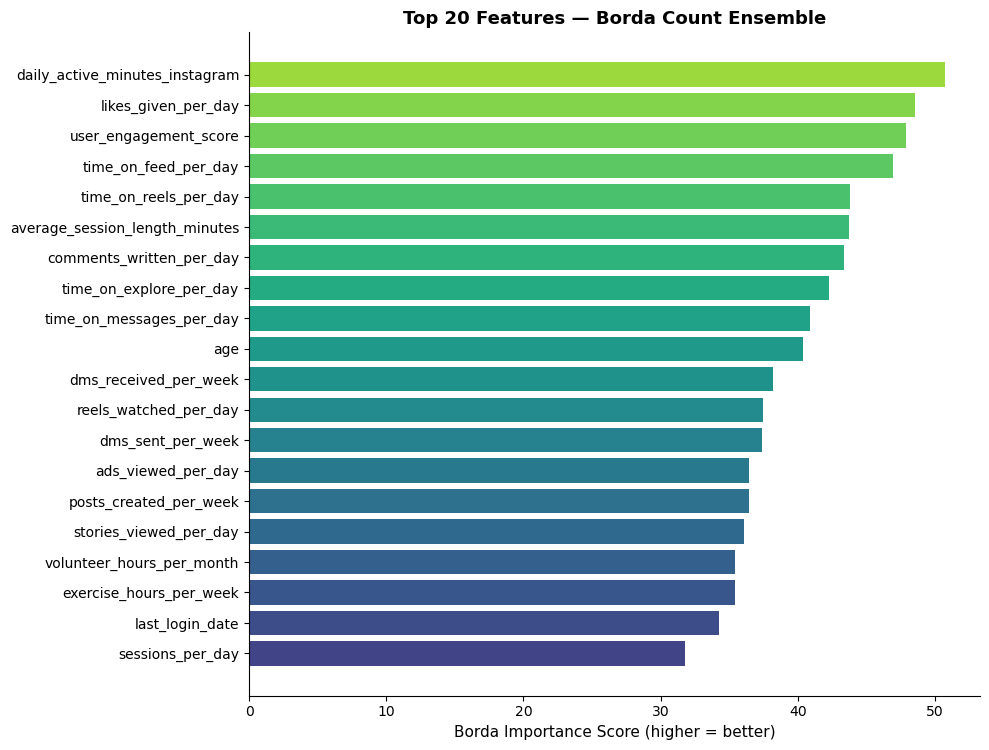

In [24]:
# ── 7B: Horizontal bar chart — Borda rank score ───────────────────────
plot_df = rank_df.head(TOP_N).copy()
# Lower Borda avg = better; flip to "importance" for plotting
max_rank = len(rank_df)
plot_df["borda_importance"] = max_rank - plot_df["borda_avg_rank"]
plot_df = plot_df.sort_values("borda_importance", ascending=True)

colours = cm.viridis(np.linspace(0.2, 0.85, len(plot_df)))

fig, ax = plt.subplots(figsize=(10, max(5, TOP_N * 0.38)))
bars = ax.barh(plot_df["feature"], plot_df["borda_importance"], color=colours)
ax.set_xlabel("Borda Importance Score (higher = better)", fontsize=11)
ax.set_title(f"Top {TOP_N} Features — Borda Count Ensemble", fontsize=13, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("top_n_borda_bar.png", dpi=130)
plt.show()

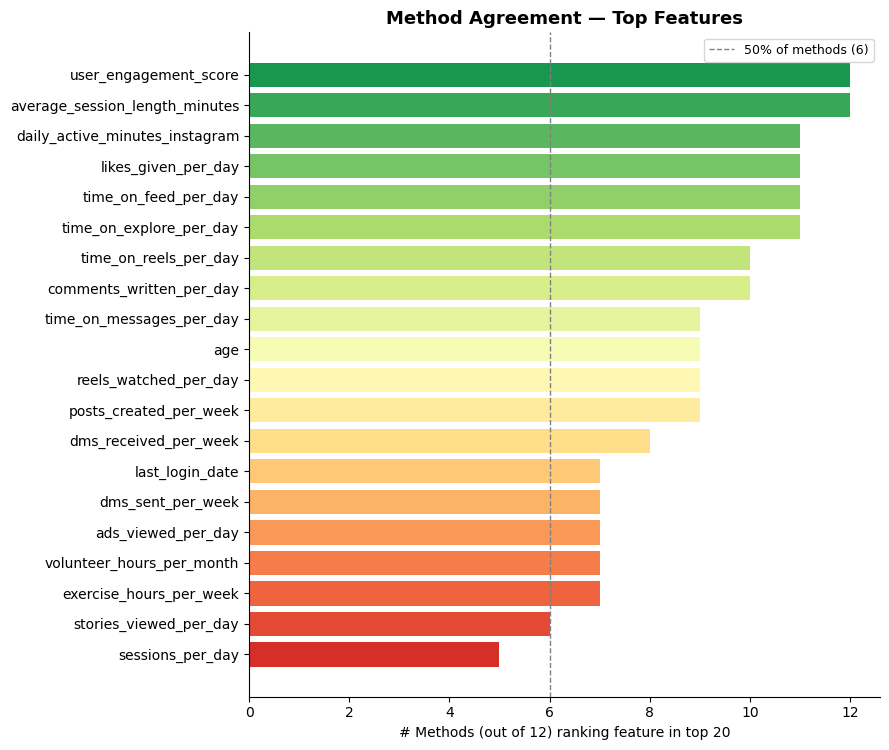

In [25]:
# ── 7C: Method agreement — how many methods rank feature in top-N ─────
n_methods = len(scores)
agreement = {}
for feat in top_n_features:
    cnt = 0
    for method_name, score_series in scores.items():
        top_n_set = set(score_series.nlargest(TOP_N).index)
        if feat in top_n_set:
            cnt += 1
    agreement[feat] = cnt

agree_df = pd.Series(agreement).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, TOP_N * 0.38)))
colours2 = cm.RdYlGn(np.linspace(0.1, 0.9, len(agree_df)))
ax.barh(agree_df.index, agree_df.values, color=colours2)
ax.axvline(n_methods * 0.5, ls="--", color="grey", lw=1, label=f"50% of methods ({n_methods//2})")
ax.set_xlabel(f"# Methods (out of {n_methods}) ranking feature in top {TOP_N}", fontsize=10)
ax.set_title("Method Agreement — Top Features", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("method_agreement.png", dpi=130)
plt.show()

In [26]:
# ── 7D: VIF table for top-N features (numeric ones) ───────────────────
print("VIF of top-N numeric features:")
top_num = [f for f in top_n_features if f in num_cols]
if top_num:
    Xv, _ = sample_xy(X_raw, y, 20_000)
    Xv = Xv[top_num].apply(pd.to_numeric, errors="coerce")
    Xv = Xv.fillna(Xv.median(numeric_only=True))
    Xv = Xv.loc[:, Xv.std() > 0]
    arr = Xv.values.astype(float)
    vif_res = [(col, variance_inflation_factor(arr, i)) for i, col in enumerate(Xv.columns)]
    vif_top = pd.DataFrame(vif_res, columns=["feature","VIF"]).sort_values("VIF", ascending=False)
    display(vif_top)

VIF of top-N numeric features:


,feature,VIF
0,daily_active_minutes_instagram,387.990220
1,likes_given_per_day,141.821483
18,last_login_date,104.758171
15,stories_viewed_per_day,96.960563
3,time_on_feed_per_day,75.780224
11,reels_watched_per_day,61.840077
6,comments_written_per_day,43.966261
10,dms_received_per_week,37.154988
12,dms_sent_per_week,34.183144
4,time_on_reels_per_day,27.549561


## 8. Summary

In [27]:
print("\n" + "="*60)
print(f"FINAL TOP-{TOP_N} FEATURES (12-method Borda ensemble)")
print("="*60)
summary = rank_df.head(TOP_N)[["final_rank","feature","borda_avg_rank"]].copy()
summary.columns = ["Rank","Feature","Avg Borda Rank"]
summary["Avg Borda Rank"] = summary["Avg Borda Rank"].round(2)
display(summary.reset_index(drop=True))

print(f"\nOutputs saved:")
print(f"  - {OUT_RANK_CSV}  (full ranking, all method scores)")
print(f"  - {OUT_TOPN_TXT}  (top-{TOP_N} feature names, one per line)")
print(f"  - rank_heatmap.png")
print(f"  - top_n_borda_bar.png")
print(f"  - method_agreement.png")
print(f"  - shap_summary.png")


FINAL TOP-20 FEATURES (12-method Borda ensemble)


,Rank,Feature,Avg Borda Rank
0,1,daily_active_minutes_instagram,4.25
1,2,likes_given_per_day,6.42
2,3,user_engagement_score,7.08
3,4,time_on_feed_per_day,8.04
4,5,time_on_reels_per_day,11.17
5,6,average_session_length_minutes,11.29
6,7,comments_written_per_day,11.62
7,8,time_on_explore_per_day,12.75
8,9,time_on_messages_per_day,14.12
9,10,age,14.62



Outputs saved:
  - feature_rankings_all_methods.csv  (full ranking, all method scores)
  - top20_features.txt  (top-20 feature names, one per line)
  - rank_heatmap.png
  - top_n_borda_bar.png
  - method_agreement.png
  - shap_summary.png
